## Importe de Librerias

In [ ]:
import pandas as pd 
import matplotlib.pyplot as plt

## Lectura de archivos 

In [ ]:
visits = pd.read_csv('C:\\repo-remoto\Showz-Analytics\\visits_log_us (1).csv')
orders = pd.read_csv('C:\\repo-remoto\Showz-Analytics\\orders_log_us.csv')
costs = pd.read_csv('C:\\repo-remoto\Showz-Analytics\\costs_us.csv')

## Informacion de los Datos 

In [21]:
visits.info()
print()
orders.info()
print()
costs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   Device     359400 non-null  object
 1   End Ts     359400 non-null  object
 2   Source Id  359400 non-null  int64 
 3   Start Ts   359400 non-null  object
 4   Uid        359400 non-null  uint64
dtypes: int64(1), object(3), uint64(1)
memory usage: 13.7+ MB

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Buy Ts   50415 non-null  object 
 1   Revenue  50415 non-null  float64
 2   Uid      50415 non-null  uint64 
dtypes: float64(1), object(1), uint64(1)
memory usage: 1.2+ MB

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2542 entries, 0 to 2541
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  

## Preparacion de los Datos

In [22]:
#Aqui realice una funcion a partir de una lista de comprehension para corregir los nombres de columna
def conv_cols(df):
    new_cols = [col.lower().replace(' ', '_') for col in df.columns]
    df.columns = new_cols
#DataFrames que necesitan el cambio se les aplica la funcion 
conv_cols(visits)
conv_cols(orders)
print(visits.columns)
print(orders.columns)

Index(['device', 'end_ts', 'source_id', 'start_ts', 'uid'], dtype='object')
Index(['buy_ts', 'revenue', 'uid'], dtype='object')


In [23]:
#Aqui me aseguro de cambiar al tipo datetime ambas columnas date
cols_vis = ['start_ts', 'end_ts']
visits[cols_vis] = visits[cols_vis].apply(pd.to_datetime)

#Cambio de variable en la tabla orders
orders['buy_ts'] = pd.to_datetime(orders['buy_ts'])

# Date time en dt de la tabla costs
costs['dt'] = pd.to_datetime(costs['dt'])

In [24]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   buy_ts   50415 non-null  datetime64[ns]
 1   revenue  50415 non-null  float64       
 2   uid      50415 non-null  uint64        
dtypes: datetime64[ns](1), float64(1), uint64(1)
memory usage: 1.2 MB


## Fraccionamiento de Fechas

In [25]:
visits_2 = visits.copy()
visits_2['session_date'] = visits['start_ts'].dt.date
visits_2['session_year'] = visits['start_ts'].dt.isocalendar().year
visits_2['session_week'] = visits['start_ts'].dt.isocalendar().week
visits_2['session_month'] = visits['start_ts'].dt.to_period('M')

## Visitas

session_date
2017-06-01    605
2017-06-02    608
2017-06-03    445
2017-06-04    476
2017-06-05    820
Name: uid, dtype: int64


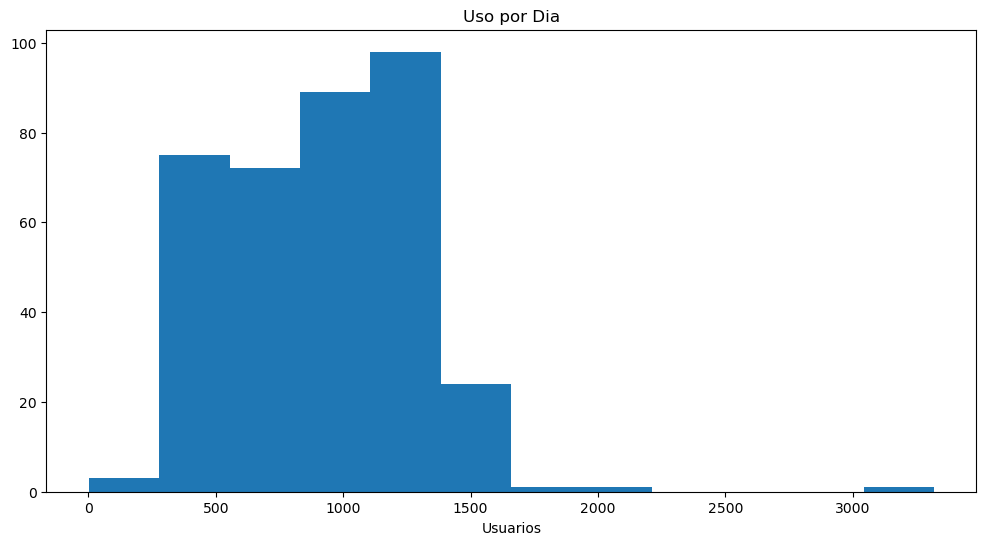

In [26]:
# Cuantas personas usan el servicio por "DIA"
dau_visits = visits_2.groupby(by= 'session_date')['uid'].nunique()
print(dau_visits.head())

#Visualizacion
plt.figure(figsize= (12, 6))
plt.hist(dau_visits, bins=12)
plt.title('Uso por Dia')
plt.xlabel('Usuarios')
plt.show()

session_year  session_week
2017          22              2021
              23              4129
              24              2812
              25              2878
              26              3064
Name: uid, dtype: int64


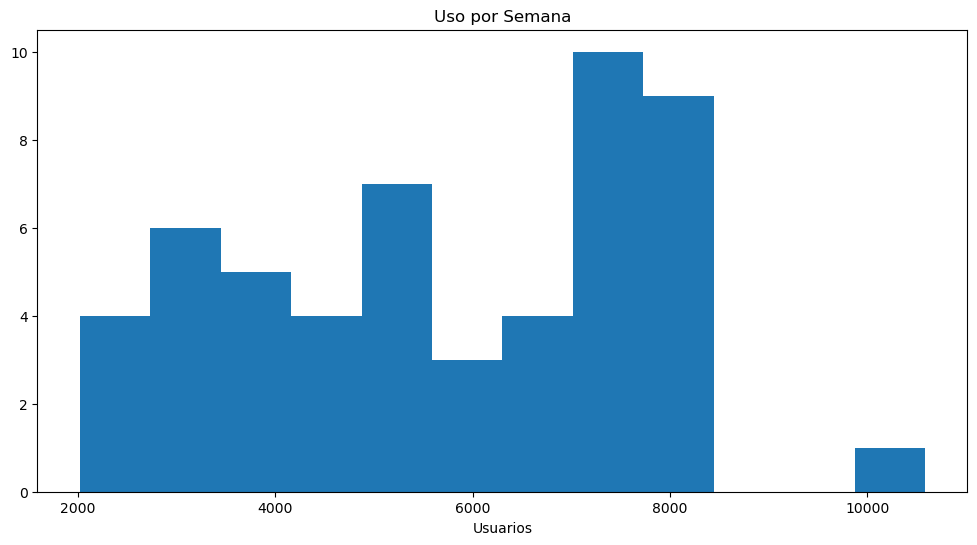

In [27]:
# Cuantas personas usan el servicio por "SEMANA"
wau_visits = visits_2.groupby(by= ['session_year', 'session_week'])['uid'].nunique()
print(wau_visits.head())

#Visualizacion
plt.figure(figsize=(12, 6))
plt.hist(wau_visits, bins=12)
plt.title('Uso por Semana')
plt.xlabel('Usuarios')
plt.show()

session_year  session_month
2017          2017-06          13259
              2017-07          14183
              2017-08          11631
              2017-09          18975
              2017-10          29692
Name: uid, dtype: int64


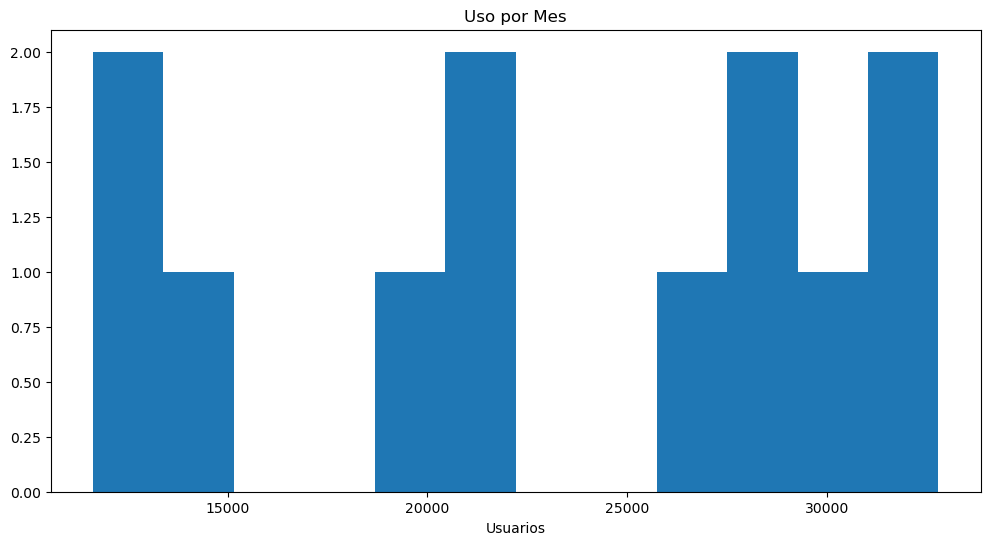

In [28]:
# Cuantas personas usan el servicio por "MES"
mau_visits = visits_2.groupby(by= ['session_year', 'session_month'])['uid'].nunique()
print(mau_visits.head())

#Visualizacion
plt.figure(figsize=(12, 6))
plt.hist(mau_visits, bins= 12)
plt.title('Uso por Mes')
plt.xlabel('Usuarios')
plt.show()

In [29]:
# Cuantas sesiones hay por dia
sessions_per_day = visits_2.groupby(by= 'session_date')['uid'].count()
print(sessions_per_day)

session_date
2017-06-01     664
2017-06-02     658
2017-06-03     477
2017-06-04     510
2017-06-05     893
              ... 
2018-05-27     672
2018-05-28    1156
2018-05-29    1035
2018-05-30    1410
2018-05-31    2256
Name: uid, Length: 364, dtype: int64


In [30]:
# Cual es la duracion de cada sesion
visits_2['session_duration'] = (visits_2['end_ts'] - visits_2['start_ts']).dt.components.minutes
print(visits_2['session_duration'].sample(15))

293718     5
219296     3
355032    19
12826      2
12999      7
177084     1
160546     1
70182     26
88015      4
140547    24
331951     1
142851     5
263539     3
203402    34
341658     0
Name: session_duration, dtype: int64


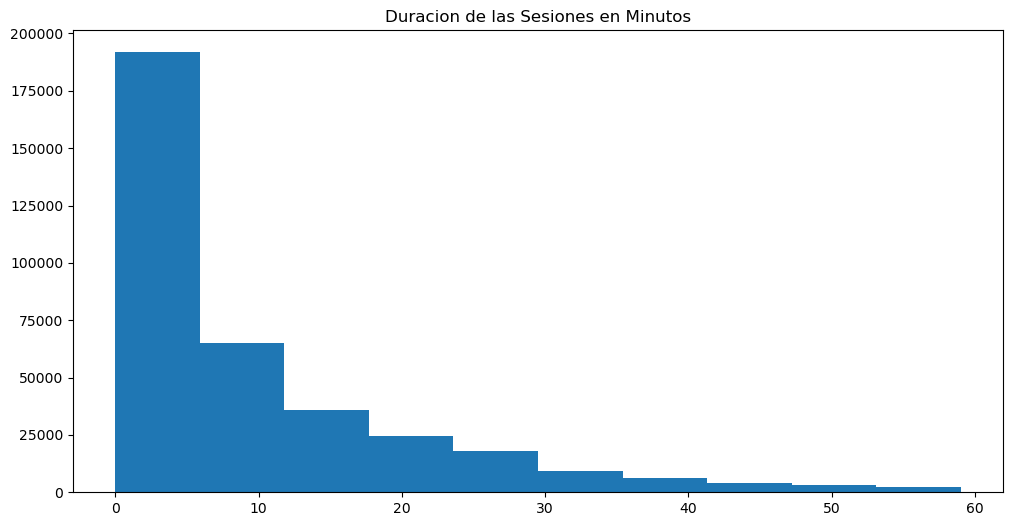

In [31]:
# Histograma de Distribucion de duracion en las sesion
plt.figure(figsize=(12, 6))
plt.hist(visits_2['session_duration'])
plt.title('Duracion de las Sesiones en Minutos')
plt.show()

In [32]:
# Con que frecuencia los usuarios regresan
visits_sorted = visits_2.sort_values(['uid', 'start_ts'])
visits_sorted['prev_sess'] = visits_sorted.groupby(by= 'uid')['start_ts'].shift(1) #Agrupar y extraer la fecha anterior en start_ts

visits_sorted['days_since_last_sess'] = (visits_sorted['start_ts'] - visits_sorted['prev_sess']).dt.days
print(visits_sorted[~visits_sorted['days_since_last_sess'].isnull()].head())

         device              end_ts  source_id            start_ts  \
192554  desktop 2018-02-18 15:26:00          2 2018-02-18 15:17:00   
113873  desktop 2018-03-11 17:29:00          2 2018-03-11 17:23:00   
41778   desktop 2018-02-26 12:34:00          5 2018-02-26 12:33:00   
141543  desktop 2017-10-21 21:44:00          2 2017-10-21 20:52:00   
130654  desktop 2018-01-08 11:37:00          2 2018-01-08 11:34:00   

                    uid session_date  session_year  session_week  \
192554  313578113262317   2018-02-18          2018             7   
113873  313578113262317   2018-03-11          2018            10   
41778   325320750514679   2018-02-26          2018             9   
141543  526778907996220   2017-10-21          2017            42   
130654  526778907996220   2018-01-08          2018             2   

       session_month  session_duration           prev_sess  \
192554       2018-02                 9 2017-09-18 22:49:00   
113873       2018-03                 6 2018-02

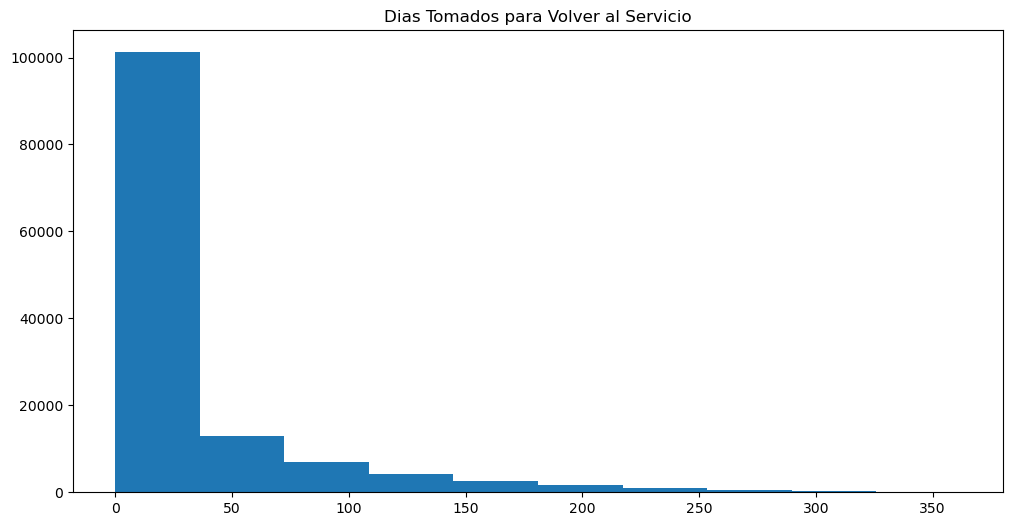

In [33]:
#Histograma de Representacion de Dias tomados para volver al servicio
visits_ = visits_sorted[~visits_sorted['days_since_last_sess'].isnull()]
plt.figure(figsize=(12, 6))
plt.hist(visits_['days_since_last_sess'])
plt.title('Dias Tomados para Volver al Servicio')
plt.show()

## Ventas

In [34]:
# Cuando empieza la gente a comprar 

# Primera session del usuario
first_visit = visits.groupby(by= 'uid')['start_ts'].min().reset_index()
first_visit.columns = ['uid', 'first_visit_ts']

# Primera compra del usuario
first_buy = orders.groupby(by= 'uid')['buy_ts'].min().reset_index()
first_buy.columns = ['uid', 'first_buy_ts']

# Conversion
conversion = pd.merge(first_visit, first_buy, on= 'uid', how= 'inner')

# Cuantos dias pasaron antes de comprar
conversion['conversion_days'] = (conversion['first_buy_ts'] - conversion['first_visit_ts']).dt.days
print(conversion.value_counts().sort_index())

uid                   first_visit_ts       first_buy_ts         conversion_days
313578113262317       2017-09-18 22:49:00  2018-01-03 21:51:00  106                1
1575281904278712      2017-06-03 10:13:00  2017-06-03 10:13:00  0                  1
2429014661409475      2017-10-11 17:14:00  2017-10-11 18:33:00  0                  1
2464366381792757      2018-01-27 20:10:00  2018-01-28 15:54:00  0                  1
2551852515556206      2017-11-24 10:14:00  2017-11-24 10:14:00  0                  1
                                                                                  ..
18445147675727495770  2017-08-20 13:30:00  2017-11-24 09:03:00  95                 1
18445407535914413204  2017-09-22 23:48:00  2017-09-22 23:55:00  0                  1
18445601152732270159  2017-08-07 11:51:00  2018-03-26 22:54:00  231                1
18446156210226471712  2017-11-07 10:01:00  2018-02-18 19:34:00  103                1
18446167067214817906  2017-10-17 10:05:00  2017-10-17 10:16:00  0     

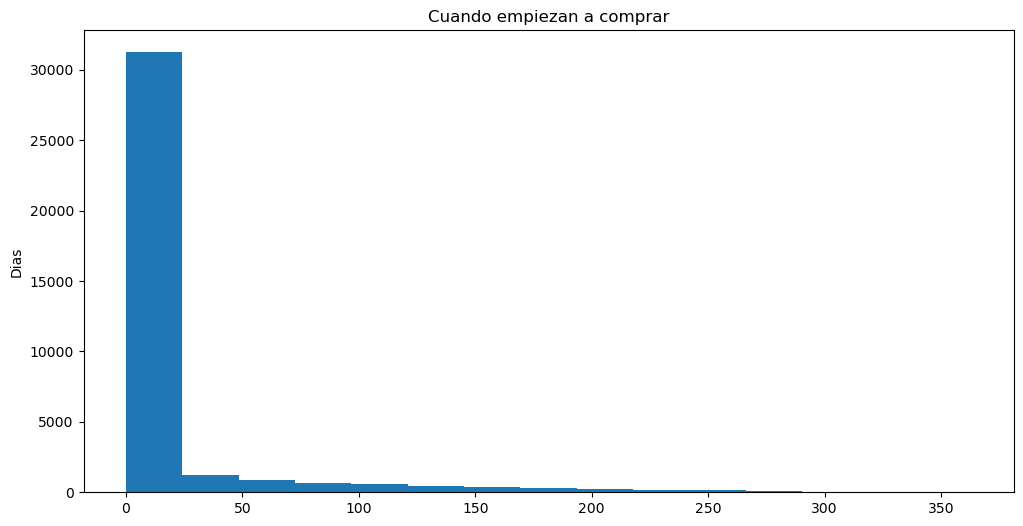

In [35]:
# Histograma representativo "Cuando compran?"
plt.figure(figsize=(12, 6))
plt.hist(conversion['conversion_days'], bins= 15)
plt.title('Cuando empiezan a comprar')
plt.ylabel('Dias')
plt.show()

In [36]:
# Cuantos pedidos hacen por dias
orders['order_date'] = orders['buy_ts'].dt.date
order_days = orders.groupby(by= 'order_date')['uid'].count().reset_index()
order_days.columns = ['order_date', 'n_orders']
print(order_days)

     order_date  n_orders
0    2017-06-01        96
1    2017-06-02       111
2    2017-06-03        67
3    2017-06-04        66
4    2017-06-05       161
..          ...       ...
359  2018-05-28       188
360  2018-05-29       189
361  2018-05-30       208
362  2018-05-31       610
363  2018-06-01         1

[364 rows x 2 columns]


In [37]:
# Cuantos pedidos hacen por mes
orders['order_month'] = orders['buy_ts'].dt.to_period('M')
order_mth = orders.groupby(by= 'order_month')['uid'].count().reset_index()
order_mth.columns = ['order_month', 'n_orders']
print(order_mth)

   order_month  n_orders
0      2017-06      2354
1      2017-07      2363
2      2017-08      1807
3      2017-09      3387
4      2017-10      5679
5      2017-11      5659
6      2017-12      6218
7      2018-01      4721
8      2018-02      5281
9      2018-03      5326
10     2018-04      3273
11     2018-05      4346
12     2018-06         1


In [38]:
# Promedio de compra
avg_rev = orders['revenue'].mean()
print(avg_rev)

4.999646930477041


In [39]:
# Cuanto dinero atrae cada cliente(LTV)
ltv = orders.groupby(by= 'uid')['revenue'].sum().reset_index()
ltv.columns = ['user', 'ltv']
print(ltv)

                       user    ltv
0           313578113262317   0.55
1          1575281904278712   3.05
2          2429014661409475  73.33
3          2464366381792757   2.44
4          2551852515556206  10.99
...                     ...    ...
36518  18445147675727495770   3.05
36519  18445407535914413204   0.88
36520  18445601152732270159   4.22
36521  18446156210226471712   9.78
36522  18446167067214817906   7.94

[36523 rows x 2 columns]


In [40]:
# LTV Promedio de los usuarios
print(ltv['ltv'].mean())

6.901327930345262


## Marketing

In [41]:
# Cuanto dinero se gasto "en total"
total_cost = costs['costs'].sum()
print(total_cost)

329131.62


In [42]:
# Cuanto dinero se gasto por "fuente de adquisicion"
source_cst = costs.groupby(by= 'source_id')['costs'].sum().reset_index()
print(source_cst)

   source_id      costs
0          1   20833.27
1          2   42806.04
2          3  141321.63
3          4   61073.60
4          5   51757.10
5          9    5517.49
6         10    5822.49


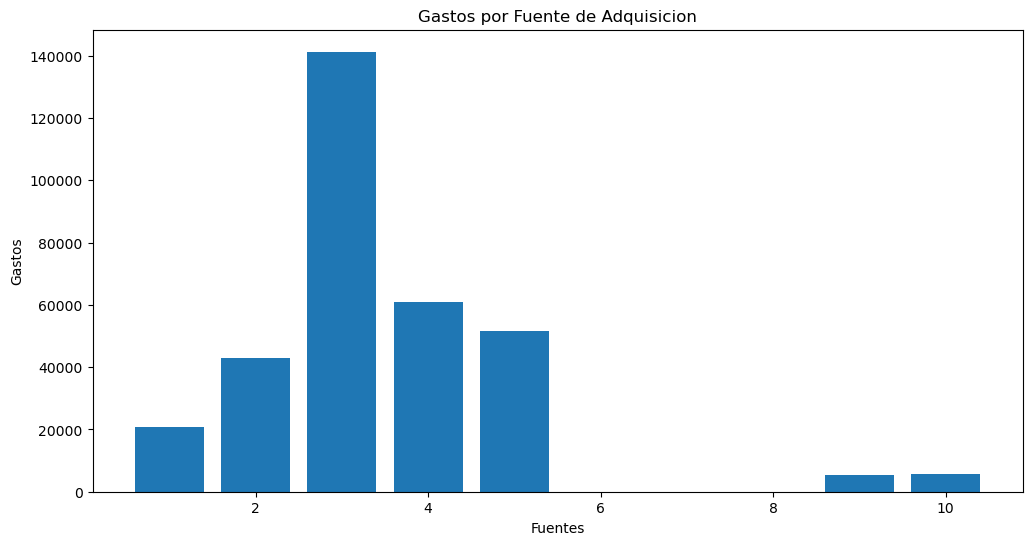

In [43]:
# Diagrama de gastos por fuente de adqusicion
plt.figure(figsize= (12, 6))
plt.bar(source_cst['source_id'], source_cst['costs'])
plt.title('Gastos por Fuente de Adquisicion')
plt.xlabel('Fuentes')
plt.ylabel('Gastos')
plt.show()

In [44]:
# Cuanto se gasta a lo largo del tiempo
costs['spent_month'] = costs['dt'].dt.to_period('M')
dt_costs = costs.groupby(by= 'spent_month')['costs'].sum().reset_index()
print(dt_costs)

   spent_month     costs
0      2017-06  18015.00
1      2017-07  18240.59
2      2017-08  14790.54
3      2017-09  24368.91
4      2017-10  36322.88
5      2017-11  37907.88
6      2017-12  38315.35
7      2018-01  33518.52
8      2018-02  32723.03
9      2018-03  30415.27
10     2018-04  22289.38
11     2018-05  22224.27


In [45]:
# Cambio de tipo de objeto para poder generar compatibilidad y graficar los meses con mas gasto para marketing
dt_costs['spent_month'] = dt_costs['spent_month'].astype(str) 

Text(0.5, 1.0, 'Gastos por Mes')

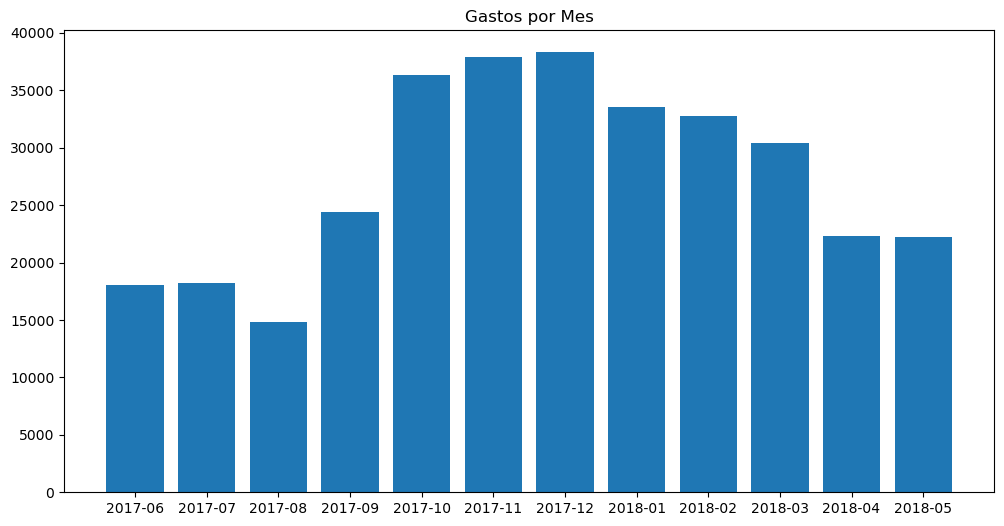

In [46]:
# Diagrama de gastos por mes
plt.figure(figsize= (12, 6))
plt.bar(dt_costs['spent_month'], dt_costs['costs'])
plt.title('Gastos por Mes')

In [47]:
# Costo por adquisicion de clientes de cada fuente(CAC)
user_per_source = visits.groupby(by= 'source_id')['uid'].nunique()

cost_per_source = costs.groupby(by= 'source_id')['costs'].sum()

cac = cost_per_source / user_per_source
cac = cac.reset_index()
cac.columns = ['source', 'cac']
print(cac)

   source       cac
0       1  1.096546
1       2  1.631017
2       3  1.890439
3       4  0.731201
4       5  0.908434
5       6       NaN
6       7       NaN
7       9  0.595584
8      10  0.721766


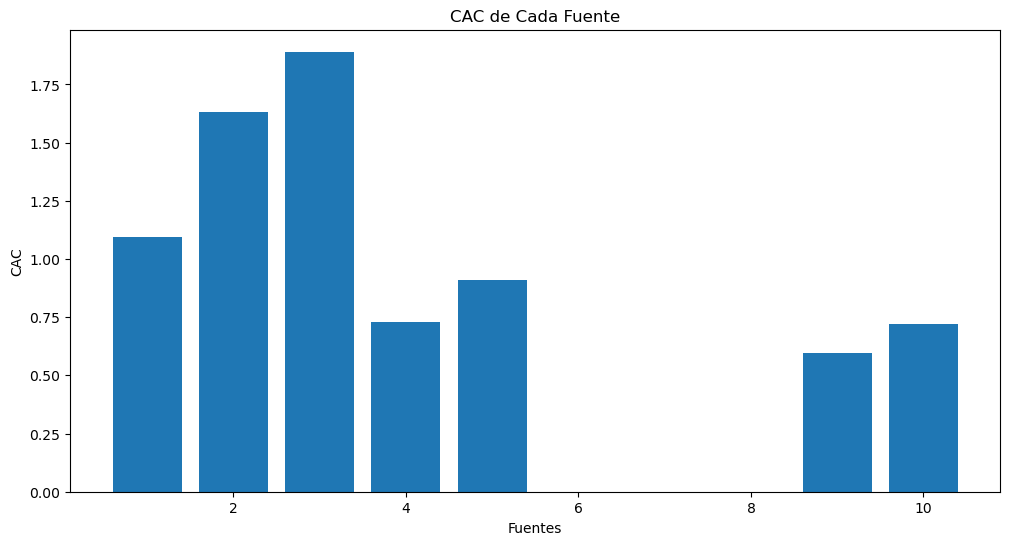

In [48]:
#Diagrama de CAC para cada fuente
plt.figure(figsize= (12, 6))
plt.bar(cac['source'], cac['cac'])
plt.title('CAC de Cada Fuente')
plt.xlabel('Fuentes')
plt.ylabel('CAC')
plt.show()

In [49]:
# Cuan rentables son las inversiones (ROMI)
ord_vis = pd.merge(orders, visits[['uid', 'source_id']], on= 'uid', how= 'left')

revenue_per_source = ord_vis.groupby(by= 'source_id')['revenue'].sum()

romi = (revenue_per_source / cost_per_source) - 1
romi = romi.reset_index()
romi.columns = ['source', 'romi']
print(romi)

   source        romi
0       1  109.313944
1       2   60.631237
2       3    1.099381
3       4    7.132649
4       5   21.827344
5       7         NaN
6       9    5.586736
7      10    1.510821


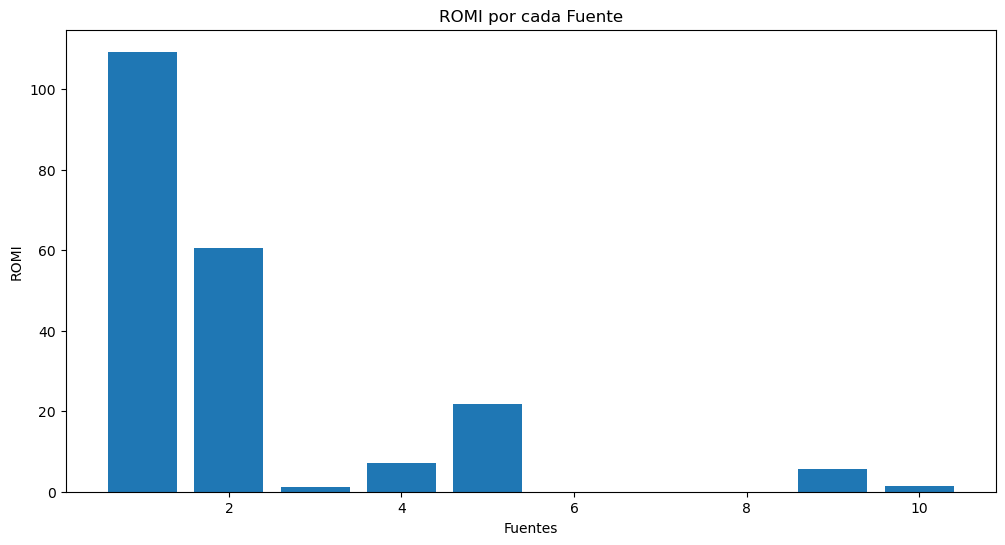

In [50]:
# Diagrama ROMI
plt.figure(figsize= (12, 6))
plt.bar(romi['source'], romi['romi'])
plt.title('ROMI por cada Fuente')
plt.xlabel('Fuentes')
plt.ylabel('ROMI')
plt.show()

## Conclusion

**Visión general del comportamiento del usuario**

El análisis del uso del servicio muestra una plataforma con actividad estable y en crecimiento durante los meses evaluados:

* Uso diario: entre ~450 y ~1200 usuarios por día al inicio; llega a >2000 sesiones por día hacia finales del período.

* Uso mensual: crecimiento sostenido hasta alcanzar picos en octubre–diciembre.

* Pedidos por mes: la conversión muestra estacionalidad con un fuerte incremento desde septiembre, alcanzando máximos en diciembre.

Esto indica una base de usuarios activa que responde bien cuando hay mayor exposición o campañas fuertes (picos de marketing coinciden con mayor actividad y órdenes).

**Economía unitaria**

* Ganancia promedio por usuario (Revenue/usuario): ≈ 5 USD

* LTV promedio estimado: ≈ 6.90 USD

El LTV es mayor que la ganancia inmediata, lo que significa que los usuarios tienen valor recurrente.

**Marketing: gasto y eficiencia**

* Gasto total en marketing: 329,131.62 USD

Se distribuye de manera desigual entre fuentes, destacándose:

* Source 3 como la más costosa (141k)

* Source 4, 5, 1, 2 como niveles intermedios

* Fuentes 9 y 10 como fuentes de bajo gasto pero no necesariamente bajo rendimiento


**Fuentes que recomendaría aumentar inversión**

Source 1 — Mejor rendimiento general

 * ROMI extremadamente alto (109x)

 * CAC bajo (1.09 USD)

 * Buena relación costo/efectividad.

 * Evidencia de alto impacto en conversiones.


Source 5 — Balance excepcional

 * ROMI muy sólido: 21.83

 * CAC bajo: 0.90 USD

 * Excelente relación de retorno con gasto moderado.


Source 4 — Bajo CAC y buen ROMI

 * CAC: 0.73 USD

 * ROMI: 7.13


Source 9 — Muy bajo CAC

 * CAC más bajo de todos: 0.59 USD

 * ROMI: 5.59


Source 10 — Aún rentable

 * CAC bajo (0.72)

 * ROMI > 1

**Recomendaciones Finales**

* Aumentar presupuesto en las fuentes 1, 5, 4 y 9 — son las más rentables y eficientes.
* Mantener y optimizar: fuente 10 y 2.
* Reducir inversión drásticamente en la fuente 3 — actualmente destruye valor.
* Suspender temporalmente fuentes sin datos (6 y 7).